In [1]:
import pandas as pd
import random
from faker import Faker

fake = Faker()

rows = 500
data = []

for i in range(rows):

    order_id = 1000 + i
    customer_name = fake.first_name()
    city = random.choice(["Delhi","Mumbai","Bangalore","Hyderabad","Pune"])
    restaurant = random.choice(["Spice Hub","Pizza Palace","Dragon Bowl","Burger Town"])
    cuisine = random.choice(["Indian","Chinese","Italian","Fast Food"])
    order_amount = random.randint(200,1200)
    payment_method = random.choice(["UPI","Cash","Card"])
    delivery_time = random.randint(20,60)
    delivery_status = random.choice(["Delivered","Late"])

    data.append([order_id,customer_name,city,restaurant,cuisine,order_amount,payment_method,delivery_time,delivery_status])

df = pd.DataFrame(data,columns=[
"order_id","customer_name","city","restaurant_name","cuisine",
"order_amount","payment_method","delivery_time","delivery_status"
])

df.to_excel("food_delivery_dataset.xlsx",index=False)

df.head()

,order_id,customer_name,city,restaurant_name,cuisine,order_amount,payment_method,delivery_time,delivery_status
0,1000,Lisa,Mumbai,Pizza Palace,Italian,1058,UPI,31,Late
1,1001,Jessica,Hyderabad,Spice Hub,Indian,545,Card,53,Delivered
2,1002,Sandy,Mumbai,Burger Town,Italian,239,UPI,35,Late
3,1003,Monica,Bangalore,Spice Hub,Italian,1009,Cash,49,Delivered
4,1004,Cameron,Bangalore,Burger Town,Italian,260,Card,32,Delivered


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("food_delivery_dataset.xlsx")

In [5]:
df.head()

,order_id,customer_name,city,restaurant_name,cuisine,order_amount,payment_method,delivery_time,delivery_status
0,1000,Lisa,Mumbai,Pizza Palace,Italian,1058,UPI,31,Late
1,1001,Jessica,Hyderabad,Spice Hub,Indian,545,Card,53,Delivered
2,1002,Sandy,Mumbai,Burger Town,Italian,239,UPI,35,Late
3,1003,Monica,Bangalore,Spice Hub,Italian,1009,Cash,49,Delivered
4,1004,Cameron,Bangalore,Burger Town,Italian,260,Card,32,Delivered


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   order_id         500 non-null    int64 
 1   customer_name    500 non-null    object
 2   city             500 non-null    object
 3   restaurant_name  500 non-null    object
 4   cuisine          500 non-null    object
 5   order_amount     500 non-null    int64 
 6   payment_method   500 non-null    object
 7   delivery_time    500 non-null    int64 
 8   delivery_status  500 non-null    object
dtypes: int64(3), object(6)
memory usage: 35.3+ KB


In [7]:
df.isnull().sum()

order_id           0
customer_name      0
city               0
restaurant_name    0
cuisine            0
order_amount       0
payment_method     0
delivery_time      0
delivery_status    0
dtype: int64

In [8]:
df.describe()

,order_id,order_amount,delivery_time
count,500.000000,500.000000,500.000000
mean,1249.500000,695.452000,40.348000
std,144.481833,297.303303,12.168609
min,1000.000000,200.000000,20.000000
25%,1124.750000,427.000000,30.000000
50%,1249.500000,704.000000,41.000000
75%,1374.250000,947.500000,51.000000
max,1499.000000,1200.000000,60.000000


In [9]:
# Orders by City
df['city'].value_counts()

city
Mumbai       131
Bangalore    110
Hyderabad     89
Delhi         89
Pune          81
Name: count, dtype: int64

In [10]:
# Most Popular Cuisine
df['cuisine'].value_counts()

cuisine
Indian       138
Chinese      125
Italian      123
Fast Food    114
Name: count, dtype: int64

In [11]:
# Payment Method Usage
df['payment_method'].value_counts()

payment_method
UPI     176
Cash    164
Card    160
Name: count, dtype: int64

In [12]:
# Revenue by City
df.groupby("city")["order_amount"].sum()

city
Bangalore    78203
Delhi        58884
Hyderabad    62193
Mumbai       86924
Pune         61522
Name: order_amount, dtype: int64

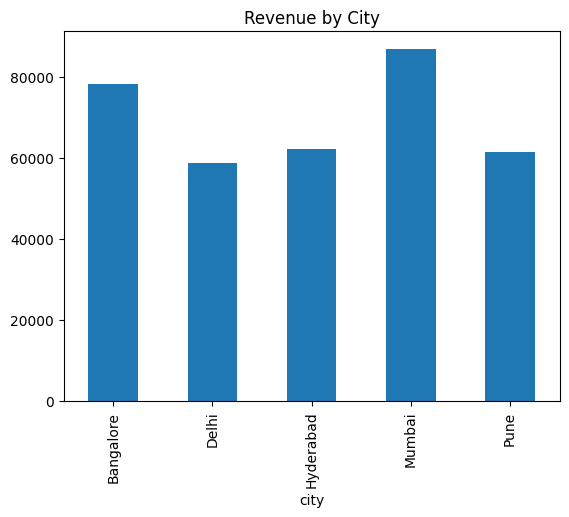

In [13]:
df.groupby("city")["order_amount"].sum().plot(kind='bar')
plt.title("Revenue by City")
plt.show()